In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings("ignore")

###############################################################################
# LOAD AND PREPARE DATA FOR EXPERIMENT 4
###############################################################################
# Load the dataset
df = pd.read_csv("hand_gesture_final_ready.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))

# Create combined label for person + gesture
# Convert gesture labels to 0-4 (up:0, down:1, play:2, pause:3, stop:4)
if 'gesture' in df.columns and 'person_id' in df.columns:
    gesture_mapping = {'up': 0, 'down': 1, 'play': 2, 'pause': 3, 'stop': 4}
    df['gesture_num'] = df['gesture'].map(gesture_mapping)
    
    # Create combined label: "gesture_person" e.g., "0_1" for up by person 1
    df['combined_label'] = df['gesture_num'].astype(str) + "_" + df['person_id'].astype(str)
    
    # Encode to integers
    le = LabelEncoder()
    y = le.fit_transform(df['combined_label'])
    
    print(f"\nCreated {len(np.unique(y))} unique combined classes")
    print(f"Sample classes: {np.unique(df['combined_label'])[:10]}")
elif 'gesture_label' in df.columns and 'person_id' in df.columns:
    # If using the second approach file
    df['gesture_num'] = df['gesture_label'] - 1  # Adjust if 1-5 maps to 0-4
    df['combined_label'] = df['gesture_num'].astype(str) + "_" + df['person_id'].astype(str)
    le = LabelEncoder()
    y = le.fit_transform(df['combined_label'])
    print(f"\nCreated {len(np.unique(y))} unique combined classes")
else:
    print("ERROR: Required columns not found!")
    exit()

# Prepare features
dist_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[dist_cols]
groups = df['person_id']

print(f"\nNumber of features: {len(dist_cols)}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Number of unique persons: {df['person_id'].nunique()}")
print(f"Total samples: {len(df)}")
print(f"Total classes: {len(np.unique(y))}")


Dataset Shape: (5226, 215)

First 3 rows:
    dist_0_1   dist_0_2   dist_0_3   dist_0_4   dist_0_5   dist_0_6  \
0  49.406727  57.021676  54.185495  41.592155  56.329099  55.366818   
1  55.879386  60.727710  59.960614  44.604987  59.966050  59.402387   
2  58.369102  63.473321  63.527602  46.510224  62.046224  60.877518   

    dist_0_7   dist_0_8   dist_0_9  dist_0_10  ...  dist_17_19  dist_17_20  \
0  54.339744  53.431505  60.348585  57.225308  ...   17.334732   18.856460   
1  57.976984  57.674575  64.561944  61.041459  ...   19.296972   17.120735   
2  59.817889  59.551658  66.523833  62.321114  ...   22.505016   20.463802   

   dist_18_19  dist_18_20  dist_19_20  person_id  person_name  gesture  \
0   55.148598   50.084830   43.870910          1     Biswadev     down   
1   46.379622   51.241909   55.025405          1     Biswadev     down   
2   48.903795   52.983701   55.718328          1     Biswadev     down   

   gesture_label  output_label  
0              2           1_2

In [4]:
###############################################################################
# DEFINE MODELS (6 algorithms, same as Experiment 3)
###############################################################################
# Define models in specified order
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42)
}

# Model order for plotting
model_order = ["Decision Tree", "SVM", "Naive Bayes", "KNN", "Logistic Regression", "Random Forest"]


In [5]:
###############################################################################
# EXPERIMENT 4: Variation of Data Size with Fixed Training Ratio (80-20)
# (Person + Gesture Classification with k-Fold CV)
###############################################################################
print("\n" + "="*80)
print("EXPERIMENT 4: Variation of Data Size with Fixed Training Ratio (80-20)")
print("Person + Gesture Classification (k-Fold Cross Validation)")
print("="*80)

# Data sizes to test (percentage of total data to use)
data_sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90]  # Percentage
k_folds = 5  # Number of folds for cross-validation
fixed_train_ratio = 0.8  # Fixed 80-20 split
results_exp4 = []

# We'll collect all metrics for different data sizes
for data_size_percent in data_sizes:
    data_size_ratio = data_size_percent / 100.0
    
    # First, take a subset of the data based on data_size_percent
    # Use GroupShuffleSplit to maintain person distribution
    gss_subset = GroupShuffleSplit(n_splits=1, train_size=data_size_ratio, random_state=42)
    subset_idx, _ = next(gss_subset.split(X, y, groups))
    
    X_subset = X.iloc[subset_idx]
    y_subset = y[subset_idx]
    groups_subset = groups.iloc[subset_idx]
    
    # Now apply 80-20 split on this subset
    gss_split = GroupShuffleSplit(n_splits=1, train_size=fixed_train_ratio, random_state=42)
    train_idx, test_idx = next(gss_split.split(X_subset, y_subset, groups_subset))
    
    # Use only training data for k-Fold CV
    X_train = X_subset.iloc[train_idx]
    y_train = y_subset[train_idx]
    X_test = X_subset.iloc[test_idx]  # Not used in CV, just for reference
    y_test = y_subset[test_idx]
    
    # Get person info for checking
    train_people = set(df.iloc[subset_idx].iloc[train_idx]['person_id'])
    test_people = set(df.iloc[subset_idx].iloc[test_idx]['person_id'])
    
    print(f"\nData Size: {data_size_percent}% of total ({len(X_subset)} samples)")
    print(f"  After 80-20 split:")
    print(f"    Training: {len(X_train)} samples, {len(train_people)} people, {len(np.unique(y_train))} classes")
    print(f"    Testing: {len(X_test)} samples, {len(test_people)} people")
    
    # Create scalers for this training subset
    minmax_scaler = MinMaxScaler()
    standard_scaler = StandardScaler()
    
    # Scale the training data
    X_train_mm = minmax_scaler.fit_transform(X_train)
    X_train_std = standard_scaler.fit_transform(X_train)
    
    print(f"  Applying {k_folds}-fold Cross Validation...")
    
    for model_name in model_order:
        model = models[model_name]
        
        # Select appropriate scaling
        if model_name in ["SVM", "KNN", "Logistic Regression"]:
            X_train_scaled = X_train_std
            scaling_used = "StandardScaler"
        else:
            X_train_scaled = X_train_mm
            scaling_used = "MinMaxScaler"
        
        # Apply k-Fold Cross Validation
        try:
            kfold = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
            cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                       cv=kfold, scoring='accuracy', n_jobs=-1)
            
            # Calculate CV metrics
            mean_cv_acc = np.mean(cv_scores)
            std_cv_acc = np.std(cv_scores)
            
            # For precision, recall, f1 - we need predictions
            precision_scores = []
            recall_scores = []
            f1_scores = []
            
            for fold_train_idx, fold_val_idx in kfold.split(X_train_scaled, y_train):
                # Get fold data
                X_fold_train = X_train_scaled[fold_train_idx]
                y_fold_train = y_train[fold_train_idx]
                X_fold_val = X_train_scaled[fold_val_idx]
                y_fold_val = y_train[fold_val_idx]
                
                # Create and fit model
                from sklearn.base import clone
                fold_model = clone(model)
                fold_model.fit(X_fold_train, y_fold_train)
                
                # Predict
                y_fold_pred = fold_model.predict(X_fold_val)
                
                # Calculate metrics
                precision_scores.append(precision_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0))
                recall_scores.append(recall_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0))
                f1_scores.append(f1_score(y_fold_val, y_fold_pred, average='weighted', zero_division=0))
            
            # Calculate mean metrics
            mean_precision = np.mean(precision_scores)
            mean_recall = np.mean(recall_scores)
            mean_f1 = np.mean(f1_scores)
            
        except Exception as e:
            print(f"    {model_name}: Error in CV - {str(e)[:100]}...")
            mean_cv_acc = np.nan
            std_cv_acc = np.nan
            mean_precision = np.nan
            mean_recall = np.nan
            mean_f1 = np.nan
        
        # Store results
        results_exp4.append([
            data_size_percent,
            model_name,
            scaling_used,
            round(mean_cv_acc, 4) if not np.isnan(mean_cv_acc) else np.nan,
            round(std_cv_acc, 4) if not np.isnan(std_cv_acc) else np.nan,
            round(mean_precision, 4) if not np.isnan(mean_precision) else np.nan,
            round(mean_recall, 4) if not np.isnan(mean_recall) else np.nan,
            round(mean_f1, 4) if not np.isnan(mean_f1) else np.nan,
            len(X_train),
            len(np.unique(y_train)),
            len(X_test)
        ])
        
        if not np.isnan(mean_cv_acc):
            print(f"    {model_name}: Accuracy = {mean_cv_acc:.4f} (±{std_cv_acc:.4f})")
        else:
            print(f"    {model_name}: Accuracy = N/A")
    
    print("-" * 50)

# Convert results to DataFrame
results_exp4_df = pd.DataFrame(results_exp4, columns=[
    "Data_Size(%)", "Model", "Scaler", "Accuracy", "Std", 
    "Precision", "Recall", "F1-Score", 
    "Train_Size", "Train_Classes", "Test_Size"
])

print("\n" + "="*80)
print("EXPERIMENT 4 RESULTS SUMMARY")
print("="*80)
print(results_exp4_df[["Data_Size(%)", "Model", "Accuracy", "Std", "F1-Score"]])



EXPERIMENT 4: Variation of Data Size with Fixed Training Ratio (80-20)
Person + Gesture Classification (k-Fold Cross Validation)

Data Size: 10% of total (524 samples)
  After 80-20 split:
    Training: 424 samples, 8 people, 40 classes
    Testing: 100 samples, 2 people
  Applying 5-fold Cross Validation...
    Decision Tree: Accuracy = 0.9504 (±0.0328)
    SVM: Accuracy = 0.9080 (±0.0329)
    Naive Bayes: Accuracy = 0.9787 (±0.0217)
    KNN: Accuracy = 0.9741 (±0.0188)
    Logistic Regression: Accuracy = 0.9740 (±0.0138)
    Random Forest: Accuracy = 0.9858 (±0.0089)
--------------------------------------------------

Data Size: 20% of total (1043 samples)
  After 80-20 split:
    Training: 843 samples, 16 people, 80 classes
    Testing: 200 samples, 4 people
  Applying 5-fold Cross Validation...
    Decision Tree: Accuracy = 0.9122 (±0.0139)
    SVM: Accuracy = 0.9395 (±0.0079)
    Naive Bayes: Accuracy = 0.9810 (±0.0058)
    KNN: Accuracy = 0.9798 (±0.0080)
    Logistic Regression

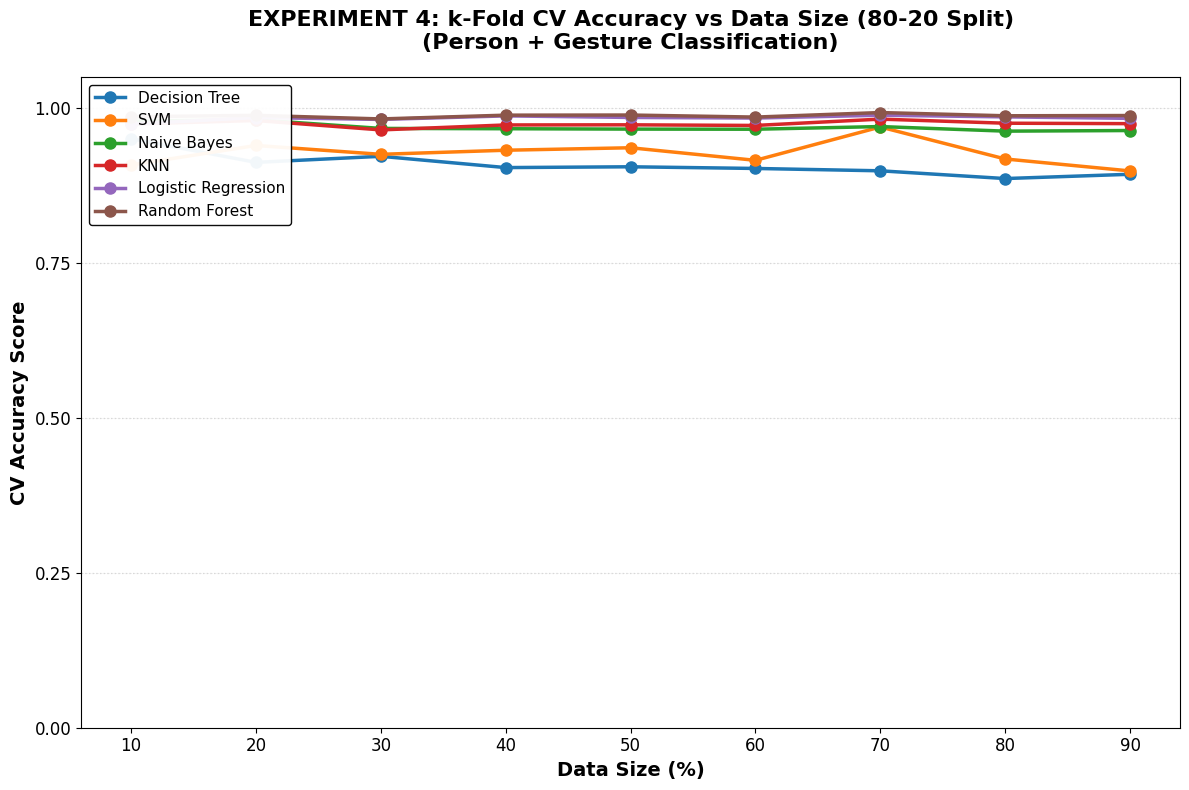

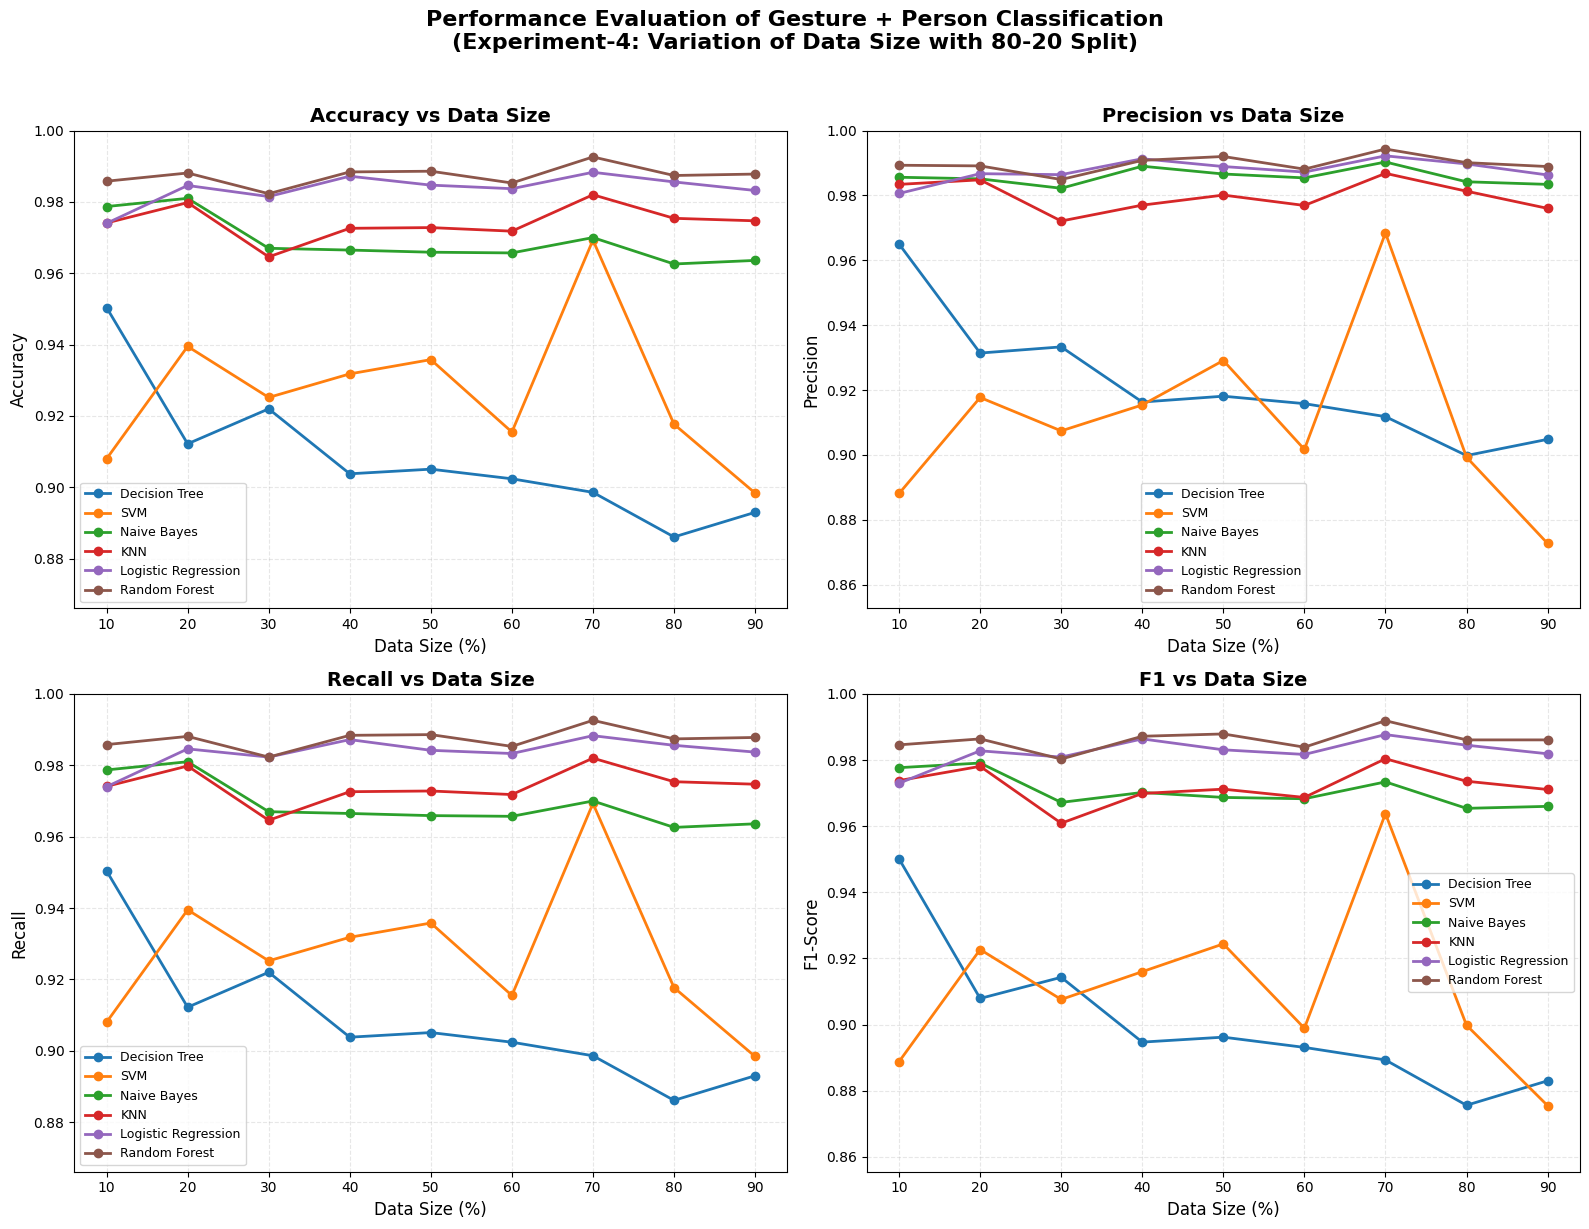

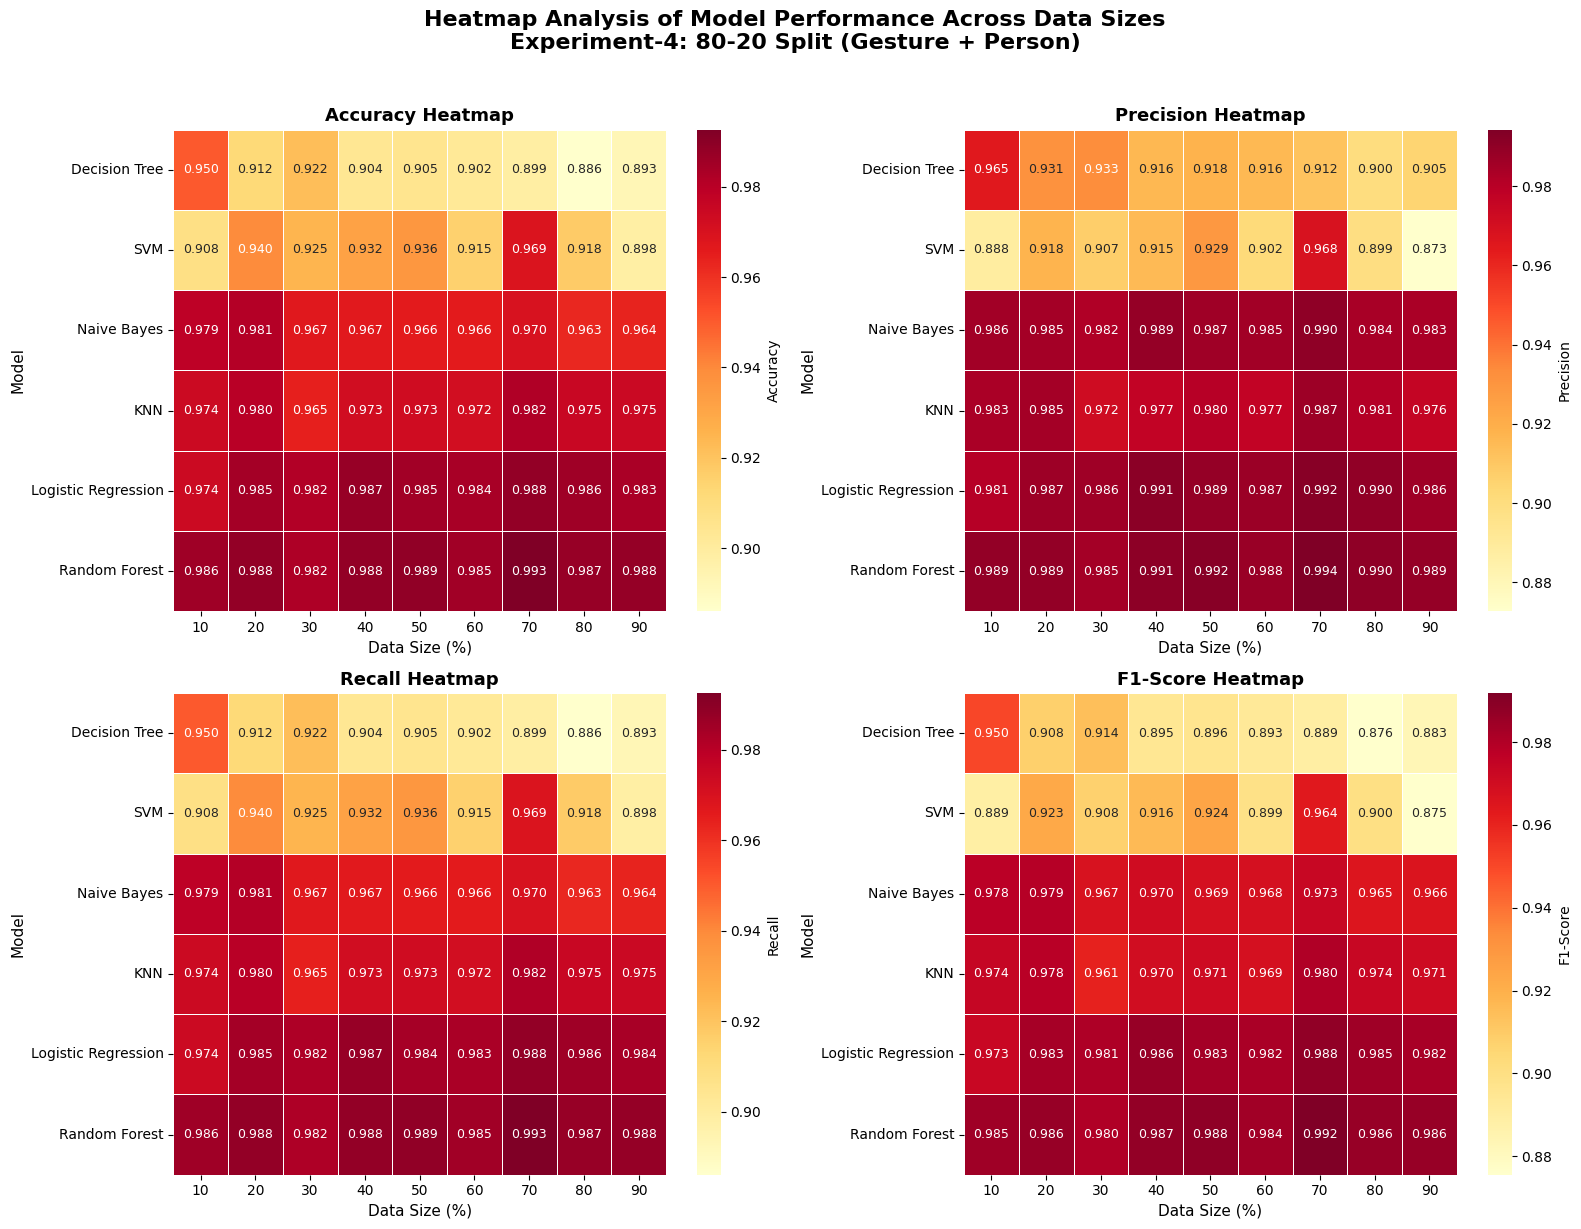

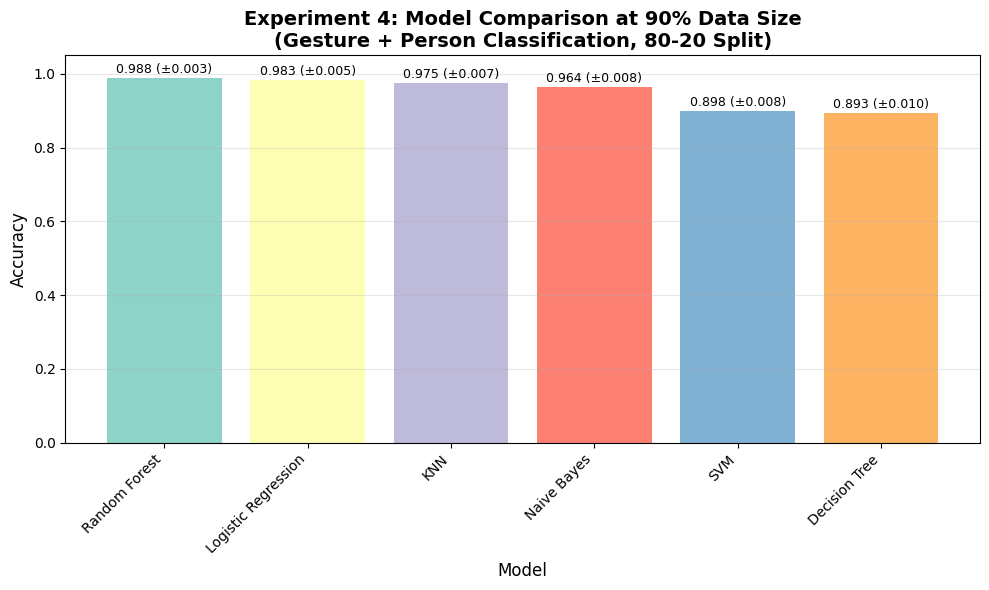


DETAILED ANALYSIS

1. BEST MODEL FOR EACH DATA SIZE (Based on Accuracy):
------------------------------------------------------------

10% Data Size:
  Best: Random Forest
  Accuracy: 0.9858 (±0.0089)
  F1-Score: 0.9846
  Training Samples: 424
  Training Classes: 40

20% Data Size:
  Best: Random Forest
  Accuracy: 0.9881 (±0.0037)
  F1-Score: 0.9864
  Training Samples: 843
  Training Classes: 80

30% Data Size:
  Best: Random Forest
  Accuracy: 0.9823 (±0.0113)
  F1-Score: 0.9803
  Training Samples: 1243
  Training Classes: 120

40% Data Size:
  Best: Random Forest
  Accuracy: 0.9884 (±0.0040)
  F1-Score: 0.9872
  Training Samples: 1643
  Training Classes: 160

50% Data Size:
  Best: Random Forest
  Accuracy: 0.9886 (±0.0060)
  F1-Score: 0.9879
  Training Samples: 2024
  Training Classes: 200

60% Data Size:
  Best: Random Forest
  Accuracy: 0.9853 (±0.0015)
  F1-Score: 0.9839
  Training Samples: 2449
  Training Classes: 239

70% Data Size:
  Best: Random Forest
  Accuracy: 0.9926 (±

In [6]:
###############################################################################
# CREATE THE MAIN GRAPH (Accuracy vs Data Size)
###############################################################################
plt.figure(figsize=(12, 8))

# Colors for models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Plot each model's Accuracy across different data sizes
for i, model_name in enumerate(model_order):
    model_data = results_exp4_df[results_exp4_df['Model'] == model_name]
    model_data = model_data.sort_values('Data_Size(%)')
    
    # Filter out NaN values
    valid_data = model_data[model_data['Accuracy'].notna()]
    
    if len(valid_data) > 0:
        plt.plot(valid_data['Data_Size(%)'], 
                 valid_data['Accuracy'], 
                 marker='o', 
                 linewidth=2.5,
                 markersize=8,
                 label=model_name,
                 color=colors[i])

# Customize the plot
plt.title('EXPERIMENT 4: k-Fold CV Accuracy vs Data Size (80-20 Split)\n(Person + Gesture Classification)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Data Size (%)', fontsize=14, fontweight='bold')
plt.ylabel('CV Accuracy Score', fontsize=14, fontweight='bold')

# Set x-axis ticks
plt.xticks(data_sizes, fontsize=12)

# Set y-axis limits and ticks
plt.ylim([0.0, 1.05])
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00], 
           ['0.00', '0.25', '0.50', '0.75', '1.00'], 
           fontsize=12)

# Add grid and reference lines
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, axis='y')
for y_val in [0.25, 0.50, 0.75, 1.00]:
    plt.axhline(y=y_val, color='gray', linestyle=':', alpha=0.2, linewidth=1)

# Add legend
plt.legend(loc='upper left', fontsize=11, framealpha=0.95, 
           edgecolor='black', fancybox=True)

plt.tight_layout()
plt.savefig('experiment4_accuracy_vs_data_size.png', dpi=300, bbox_inches='tight')
plt.show()

###############################################################################
# CREATE 4 METRICS PLOT (Like Experiment 3)
###############################################################################
plt.figure(figsize=(16, 12))

# Create subplots for 4 metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
titles = ['Accuracy vs Data Size', 'Precision vs Data Size', 
          'Recall vs Data Size', 'F1 vs Data Size']

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    
    # Plot each model
    for j, model_name in enumerate(model_order):
        model_data = results_exp4_df[results_exp4_df['Model'] == model_name]
        model_data = model_data.sort_values('Data_Size(%)')
        
        # Filter out NaN values
        valid_data = model_data[model_data[metric].notna()]
        
        if len(valid_data) > 0:
            plt.plot(valid_data['Data_Size(%)'], valid_data[metric], 
                     marker='o', linewidth=2, markersize=6,
                     label=model_name, color=colors[j])
    
    # Customize subplot
    plt.title(titles[i], fontsize=14, fontweight='bold')
    plt.xlabel('Data Size (%)', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(data_sizes)
    
    # Set y-axis limits based on data
    all_metrics = results_exp4_df[metric].dropna()
    if len(all_metrics) > 0:
        min_val = all_metrics.min() - 0.02
        max_val = all_metrics.max() + 0.02
        plt.ylim([max(0, min_val), min(1.0, max_val)])
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=9, loc='best')

plt.suptitle('Performance Evaluation of Gesture + Person Classification\n(Experiment-4: Variation of Data Size with 80-20 Split)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('experiment4_4_metrics_plot.png', dpi=300, bbox_inches='tight')
plt.show()

###############################################################################
# CREATE HEATMAPS FOR DIFFERENT DATA SIZES
###############################################################################
# Create a figure with 4 heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Metrics for heatmaps
heatmap_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
heatmap_titles = ['Accuracy Heatmap', 'Precision Heatmap', 
                  'Recall Heatmap', 'F1-Score Heatmap']

for idx, (metric, title) in enumerate(zip(heatmap_metrics, heatmap_titles)):
    ax = axes[idx//2, idx%2]
    
    # Create pivot table
    heatmap_data = results_exp4_df.pivot_table(
        index='Model', 
        columns='Data_Size(%)', 
        values=metric,
        aggfunc='mean'
    )
    
    # Reorder models
    heatmap_data = heatmap_data.reindex(model_order)
    
    # Create mask for NaN values
    mask = heatmap_data.isna()
    
    # Create heatmap
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
                linewidths=0.5, ax=ax, cbar_kws={'label': metric},
                annot_kws={"size": 9}, mask=mask)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Data Size (%)', fontsize=11)
    ax.set_ylabel('Model', fontsize=11)

plt.suptitle('Heatmap Analysis of Model Performance Across Data Sizes\nExperiment-4: 80-20 Split (Gesture + Person)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('experiment4_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

###############################################################################
# CREATE COMPARISON PLOT AT MAX DATA SIZE (90%)
###############################################################################
plt.figure(figsize=(10, 6))

# Get data for 90% data size
max_data_size = 90
max_data = results_exp4_df[results_exp4_df['Data_Size(%)'] == max_data_size]

# Sort by Accuracy
max_data = max_data.sort_values('Accuracy', ascending=False)

# Create bar chart
bars = plt.bar(range(len(max_data)), max_data['Accuracy'], 
               color=plt.cm.Set3(np.arange(len(max_data))))

# Customize
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Experiment 4: Model Comparison at {max_data_size}% Data Size\n(Gesture + Person Classification, 80-20 Split)', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(max_data)), max_data['Model'], rotation=45, ha='right')

# Add value labels on bars
for bar, acc, std in zip(bars, max_data['Accuracy'], max_data['Std']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{acc:.3f} (±{std:.3f})', ha='center', va='bottom', fontsize=9)

plt.ylim([0.0, 1.05])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('experiment4_90_percent_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

###############################################################################
# DETAILED ANALYSIS
###############################################################################
print("\n" + "="*80)
print("DETAILED ANALYSIS")
print("="*80)

# Filter out models with NaN values
valid_results = results_exp4_df[results_exp4_df['Accuracy'].notna()]

if len(valid_results) > 0:
    # 1. Best model for each data size
    print("\n1. BEST MODEL FOR EACH DATA SIZE (Based on Accuracy):")
    print("-" * 60)

    for size in sorted(valid_results['Data_Size(%)'].unique()):
        size_data = valid_results[valid_results['Data_Size(%)'] == size]
        if len(size_data) > 0:
            best_model = size_data.loc[size_data['Accuracy'].idxmax()]
            
            print(f"\n{size}% Data Size:")
            print(f"  Best: {best_model['Model']}")
            print(f"  Accuracy: {best_model['Accuracy']:.4f} (±{best_model['Std']:.4f})")
            print(f"  F1-Score: {best_model['F1-Score']:.4f}")
            print(f"  Training Samples: {best_model['Train_Size']}")
            print(f"  Training Classes: {best_model['Train_Classes']}")

    # 2. Overall best model (average across all data sizes)
    print("\n\n2. OVERALL BEST MODEL (Average across all data sizes):")
    print("-" * 60)

    # Calculate average metrics for each model
    model_avg = valid_results.groupby('Model').agg({
        'Accuracy': ['mean', 'std'],
        'Precision': 'mean',
        'Recall': 'mean',
        'F1-Score': 'mean',
        'Std': 'mean'
    }).round(4)

    model_avg.columns = ['Mean_Accuracy', 'Std_Accuracy', 'Mean_Precision', 
                        'Mean_Recall', 'Mean_F1', 'Mean_CV_Std']
    model_avg = model_avg.sort_values('Mean_Accuracy', ascending=False)

    print("\nModel Performance Ranking (across all data sizes):")
    for i, (model_name, row) in enumerate(model_avg.iterrows(), 1):
        print(f"  {i}. {model_name}: Accuracy={row['Mean_Accuracy']:.4f}, "
              f"F1={row['Mean_F1']:.4f}, Std={row['Mean_CV_Std']:.4f}")

    # 3. Model consistency
    print("\n\n3. MODEL CONSISTENCY (Lower CV Std = More Consistent):")
    print("-" * 60)

    consistency = valid_results.groupby('Model')['Std'].mean().round(4).sort_values()

    print("\nAverage CV Standard Deviation (lower is better):")
    for i, (model, std) in enumerate(consistency.items(), 1):
        print(f"  {i}. {model}: {std}")

    # 4. Performance improvement with more data
    print("\n\n4. PERFORMANCE IMPROVEMENT WITH MORE DATA:")
    print("-" * 60)

    improvement_data = []
    for model_name in model_order:
        # Get accuracy at 10% data size
        small = valid_results[(valid_results['Model'] == model_name) & 
                           (valid_results['Data_Size(%)'] == 10)]['Accuracy'].values
        # Get accuracy at 90% data size
        large = valid_results[(valid_results['Model'] == model_name) & 
                           (valid_results['Data_Size(%)'] == 90)]['Accuracy'].values
        
        if len(small) > 0 and len(large) > 0:
            improvement = large[0] - small[0]
            percent_improvement = (improvement / small[0]) * 100 if small[0] > 0 else 0
            improvement_data.append((model_name, improvement, percent_improvement))

    if improvement_data:
        improvement_data.sort(key=lambda x: x[1], reverse=True)
        print("\nImprovement from 10% to 90% data size:")
        for model_name, improvement, percent_improve in improvement_data:
            if improvement > 0:
                print(f"  {model_name}: +{improvement:.4f} ({percent_improve:.1f}%)")
            elif improvement < 0:
                print(f"  {model_name}: {improvement:.4f} ({percent_improve:.1f}%)")
            else:
                print(f"  {model_name}: No change")
    else:
        print("\nCannot calculate improvement - missing data for some sizes")
    
    # 5. Data efficiency analysis
    print("\n\n5. DATA EFFICIENCY ANALYSIS:")
    print("-" * 60)
    
    print("\nModels that reach 95% of their max accuracy with least data:")
    for model_name in model_order:
        model_data = valid_results[valid_results['Model'] == model_name].sort_values('Data_Size(%)')
        if len(model_data) > 0:
            max_acc = model_data['Accuracy'].max()
            target_acc = 0.95 * max_acc
            
            # Find smallest data size that reaches target accuracy
            reaching_sizes = model_data[model_data['Accuracy'] >= target_acc]
            if len(reaching_sizes) > 0:
                min_size = reaching_sizes['Data_Size(%)'].min()
                acc_at_min = reaching_sizes.iloc[0]['Accuracy']
                print(f"  {model_name}: {min_size}% data ({acc_at_min:.4f} accuracy)")
    
    # 6. Saturation point analysis
    print("\n\n6. SATURATION POINT ANALYSIS:")
    print("-" * 60)
    
    print("\nData size where accuracy improvement becomes minimal (<1%):")
    for model_name in model_order:
        model_data = valid_results[valid_results['Model'] == model_name].sort_values('Data_Size(%)')
        if len(model_data) > 1:
            # Calculate improvements between consecutive data sizes
            improvements = []
            sizes = []
            for i in range(1, len(model_data)):
                prev_acc = model_data.iloc[i-1]['Accuracy']
                curr_acc = model_data.iloc[i]['Accuracy']
                prev_size = model_data.iloc[i-1]['Data_Size(%)']
                curr_size = model_data.iloc[i]['Data_Size(%)']
                
                improvement = curr_acc - prev_acc
                improvements.append(improvement)
                sizes.append(curr_size)
            
            # Find where improvement drops below 1%
            for i, (size, imp) in enumerate(zip(sizes, improvements)):
                if imp < 0.01:  # Less than 1% improvement
                    print(f"  {model_name}: Saturation at {size}% data")
                    break
            else:
                print(f"  {model_name}: No clear saturation point")

else:
    print("No models produced valid CV scores!")

###############################################################################
# SAVE RESULTS
###############################################################################
results_exp4_df.to_csv('experiment4_results.csv', index=False)

print("\n" + "="*80)
print("EXPERIMENT 4 COMPLETED SUCCESSFULLY")
print("="*80)
print(f"Results saved to 'experiment4_results.csv'")
print(f"Main graph saved to 'experiment4_accuracy_vs_data_size.png'")
print(f"4-metrics plot saved to 'experiment4_4_metrics_plot.png'")
print(f"Heatmaps saved to 'experiment4_heatmaps.png'")
print(f"Bar chart saved to 'experiment4_90_percent_comparison.png'")

print("\nExperiment 4 Summary:")
print(f"- Task: Person + Gesture classification")
print(f"- Fixed split: 80-20 (training-testing)")
print(f"- Data sizes tested: {', '.join(map(str, data_sizes))}% of total data")
print(f"- Method: {k_folds}-Fold Cross Validation")
print(f"- Models tested: {', '.join(model_order)}")